In [ ]:
# Task 3: Event Impact Modeling
# Ethiopia Financial Inclusion Forecasting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import files
print("Please upload ethiopia_fi_unified_data.xlsx")
uploaded = files.upload()

import os
raw_data_path = None
for filename in uploaded.keys():
    if 'ethiopia_fi_unified_data' in filename:
        raw_data_path = filename
        break

df = pd.read_excel(raw_data_path)
print(f"Data loaded: {df.shape}")

Mounted at /content/drive
Please upload ethiopia_fi_unified_data.xlsx


Saving ethiopia_fi_unified_data.xlsx to ethiopia_fi_unified_data.xlsx
Data loaded: (43, 34)


In [4]:
observations = df[df['record_type'] == 'observation']
events = df[df['record_type'] == 'event']
impact_links = df[df['record_type'] == 'impact_link']
targets = df[df['record_type'] == 'target']

print(f"Observations: {len(observations)}")
print(f"Events: {len(events)}")
print(f"Impact Links: {len(impact_links)}")
print(f"Targets: {len(targets)}")

if len(impact_links) == 0:
    print("\nNo impact links found - we need to create them")

Observations: 30
Events: 10
Impact Links: 0
Targets: 3

No impact links found - we need to create them


In [5]:
print("=" * 80)
print("CATALOGED EVENTS")
print("=" * 80)

name_col = None
for col in ['name', 'event_name', 'indicator']:
    if col in events.columns:
        name_col = col
        break

event_cols = ['observation_date', 'category']
if name_col:
    event_cols.insert(0, name_col)

print(events[event_cols].to_string(index=False))

CATALOGED EVENTS
                             indicator observation_date       category
                       Telebirr Launch       2021-05-17 product_launch
  Safaricom Ethiopia Commercial Launch       2022-08-01   market_entry
                M-Pesa Ethiopia Launch       2023-08-01 product_launch
      Fayda Digital ID Program Rollout       2024-01-01 infrastructure
       Foreign Exchange Liberalization       2024-07-29         policy
   P2P Transaction Count Surpasses ATM       2024-10-01      milestone
          M-Pesa EthSwitch Integration       2025-10-27    partnership
EthioPay Instant Payment System Launch       2025-12-18 infrastructure
               NFIS-II Strategy Launch       2021-09-01         policy
     Safaricom Ethiopia Price Increase       2025-12-15        pricing


In [6]:
print("=" * 80)
print("AVAILABLE INDICATORS")
print("=" * 80)

indicator_cols = ['indicator_code', 'indicator', 'pillar']
available = [col for col in indicator_cols if col in observations.columns]
print(observations[available].drop_duplicates().to_string(index=False))

print("\n" + "=" * 40)
print("INDICATOR SUMMARY")
print("=" * 40)

indicator_summary = observations.groupby('indicator_code').agg({
    'value_numeric': ['min', 'max', 'mean'],
    'observation_date': ['min', 'max']
}).round(2)
indicator_summary.columns = ['min', 'max', 'mean', 'first_date', 'last_date']
print(indicator_summary)

AVAILABLE INDICATORS
    indicator_code                         indicator        pillar
     ACC_OWNERSHIP            Account Ownership Rate        ACCESS
    ACC_MM_ACCOUNT         Mobile Money Account Rate        ACCESS
        ACC_4G_COV            4G Population Coverage        ACCESS
    ACC_MOBILE_PEN   Mobile Subscription Penetration        ACCESS
         ACC_FAYDA       Fayda Digital ID Enrollment        ACCESS
     USG_P2P_COUNT             P2P Transaction Count         USAGE
     USG_P2P_VALUE             P2P Transaction Value         USAGE
     USG_ATM_COUNT             ATM Transaction Count         USAGE
     USG_ATM_VALUE             ATM Transaction Value         USAGE
     USG_CROSSOVER           P2P/ATM Crossover Ratio         USAGE
USG_TELEBIRR_USERS         Telebirr Registered Users         USAGE
USG_TELEBIRR_VALUE        Telebirr Transaction Value         USAGE
   USG_MPESA_USERS           M-Pesa Registered Users         USAGE
  USG_MPESA_ACTIVE        M-Pesa 90-Day A

In [7]:
print("=" * 80)
print("EVENT-INDICATOR ASSOCIATION MATRIX")
print("=" * 80)

event_names = []
if 'name' in events.columns:
    event_names = events['name'].tolist()
elif 'event_name' in events.columns:
    event_names = events['event_name'].tolist()
elif 'indicator' in events.columns:
    event_names = events['indicator'].tolist()

indicators = observations['indicator_code'].unique().tolist()

association_matrix = pd.DataFrame(0, index=event_names, columns=indicators)

print("Initial Association Matrix (all zeros):")
print(association_matrix)

print("\n" + "=" * 40)
print("MATRIX SHAPE")
print("=" * 40)
print(f"Events: {len(event_names)}")
print(f"Indicators: {len(indicators)}")

EVENT-INDICATOR ASSOCIATION MATRIX
Initial Association Matrix (all zeros):
                                        ACC_OWNERSHIP  ACC_MM_ACCOUNT  \
Telebirr Launch                                     0               0   
Safaricom Ethiopia Commercial Launch                0               0   
M-Pesa Ethiopia Launch                              0               0   
Fayda Digital ID Program Rollout                    0               0   
Foreign Exchange Liberalization                     0               0   
P2P Transaction Count Surpasses ATM                 0               0   
M-Pesa EthSwitch Integration                        0               0   
EthioPay Instant Payment System Launch              0               0   
NFIS-II Strategy Launch                             0               0   
Safaricom Ethiopia Price Increase                   0               0   

                                        ACC_4G_COV  ACC_MOBILE_PEN  ACC_FAYDA  \
Telebirr Launch                         

In [8]:
print("=" * 80)
print("DEFINE EVENT IMPACTS")
print("=" * 80)

impact_entries = []

print("Enter impact details for each event.\n")
print("For each event, specify which indicators it affects:")
print("Format: event_name, indicator_code, direction, magnitude, lag_months")
print("Example: Telebirr Launch, ACC_OWNERSHIP, positive, 3.0, 12")
print("Type 'done' when finished\n")

# Pre-defined impacts based on Ethiopia context
impact_data = [
    # Event, Indicator, Direction, Magnitude, Lag(months)
    ("Telebirr Launch", "ACC_OWNERSHIP", "positive", 3.0, 12),
    ("Telebirr Launch", "ACC_MM_ACCOUNT", "positive", 4.5, 6),
    ("Telebirr Launch", "USG_DIGITAL_PAYMENT", "positive", 5.0, 12),
    ("M-Pesa Entry", "ACC_MM_ACCOUNT", "positive", 3.0, 6),
    ("M-Pesa Entry", "USG_DIGITAL_PAYMENT", "positive", 4.0, 12),
    ("EthSwitch Interoperability", "USG_DIGITAL_PAYMENT", "positive", 2.0, 3),
    ("Fayda Digital ID Launch", "ACC_OWNERSHIP", "positive", 1.5, 12),
    ("Fayda Digital ID Launch", "ACC_MM_ACCOUNT", "positive", 2.0, 6),
    ("4G Network Expansion", "ACC_MM_ACCOUNT", "positive", 1.0, 18),
    ("4G Network Expansion", "USG_DIGITAL_PAYMENT", "positive", 1.5, 12)
]

print("Pre-defined impacts based on literature and comparable countries:\n")
for event, indicator, direction, magnitude, lag in impact_data:
    print(f"  {event} -> {indicator}: {direction}, {magnitude}pp, lag {lag} months")
    impact_entries.append({
        'event': event,
        'indicator': indicator,
        'direction': direction,
        'magnitude': magnitude,
        'lag_months': lag
    })

print("\n" + "=" * 40)
print("IMPACT ENTRIES")
print("=" * 40)
impact_df = pd.DataFrame(impact_entries)
print(impact_df.to_string(index=False))

DEFINE EVENT IMPACTS
Enter impact details for each event.

For each event, specify which indicators it affects:
Format: event_name, indicator_code, direction, magnitude, lag_months
Example: Telebirr Launch, ACC_OWNERSHIP, positive, 3.0, 12
Type 'done' when finished

Pre-defined impacts based on literature and comparable countries:

  Telebirr Launch -> ACC_OWNERSHIP: positive, 3.0pp, lag 12 months
  Telebirr Launch -> ACC_MM_ACCOUNT: positive, 4.5pp, lag 6 months
  Telebirr Launch -> USG_DIGITAL_PAYMENT: positive, 5.0pp, lag 12 months
  M-Pesa Entry -> ACC_MM_ACCOUNT: positive, 3.0pp, lag 6 months
  M-Pesa Entry -> USG_DIGITAL_PAYMENT: positive, 4.0pp, lag 12 months
  EthSwitch Interoperability -> USG_DIGITAL_PAYMENT: positive, 2.0pp, lag 3 months
  Fayda Digital ID Launch -> ACC_OWNERSHIP: positive, 1.5pp, lag 12 months
  Fayda Digital ID Launch -> ACC_MM_ACCOUNT: positive, 2.0pp, lag 6 months
  4G Network Expansion -> ACC_MM_ACCOUNT: positive, 1.0pp, lag 18 months
  4G Network Expans

In [11]:
import os
os.makedirs('reports', exist_ok=True)

print("=" * 80)
print("POPULATED ASSOCIATION MATRIX")
print("=" * 80)

for entry in impact_entries:
    event = entry['event']
    indicator = entry['indicator']
    magnitude = entry['magnitude']

    if event in association_matrix.index and indicator in association_matrix.columns:
        association_matrix.loc[event, indicator] = magnitude

print(association_matrix)

association_matrix.to_csv('reports/association_matrix.csv')
print("\nAssociation matrix saved to reports/association_matrix.csv")

POPULATED ASSOCIATION MATRIX
                                        ACC_OWNERSHIP  ACC_MM_ACCOUNT  \
Telebirr Launch                                     3             4.5   
Safaricom Ethiopia Commercial Launch                0             0.0   
M-Pesa Ethiopia Launch                              0             0.0   
Fayda Digital ID Program Rollout                    0             0.0   
Foreign Exchange Liberalization                     0             0.0   
P2P Transaction Count Surpasses ATM                 0             0.0   
M-Pesa EthSwitch Integration                        0             0.0   
EthioPay Instant Payment System Launch              0             0.0   
NFIS-II Strategy Launch                             0             0.0   
Safaricom Ethiopia Price Increase                   0             0.0   

                                        ACC_4G_COV  ACC_MOBILE_PEN  ACC_FAYDA  \
Telebirr Launch                                  0               0          0   
Safar

ASSOCIATION MATRIX HEATMAP


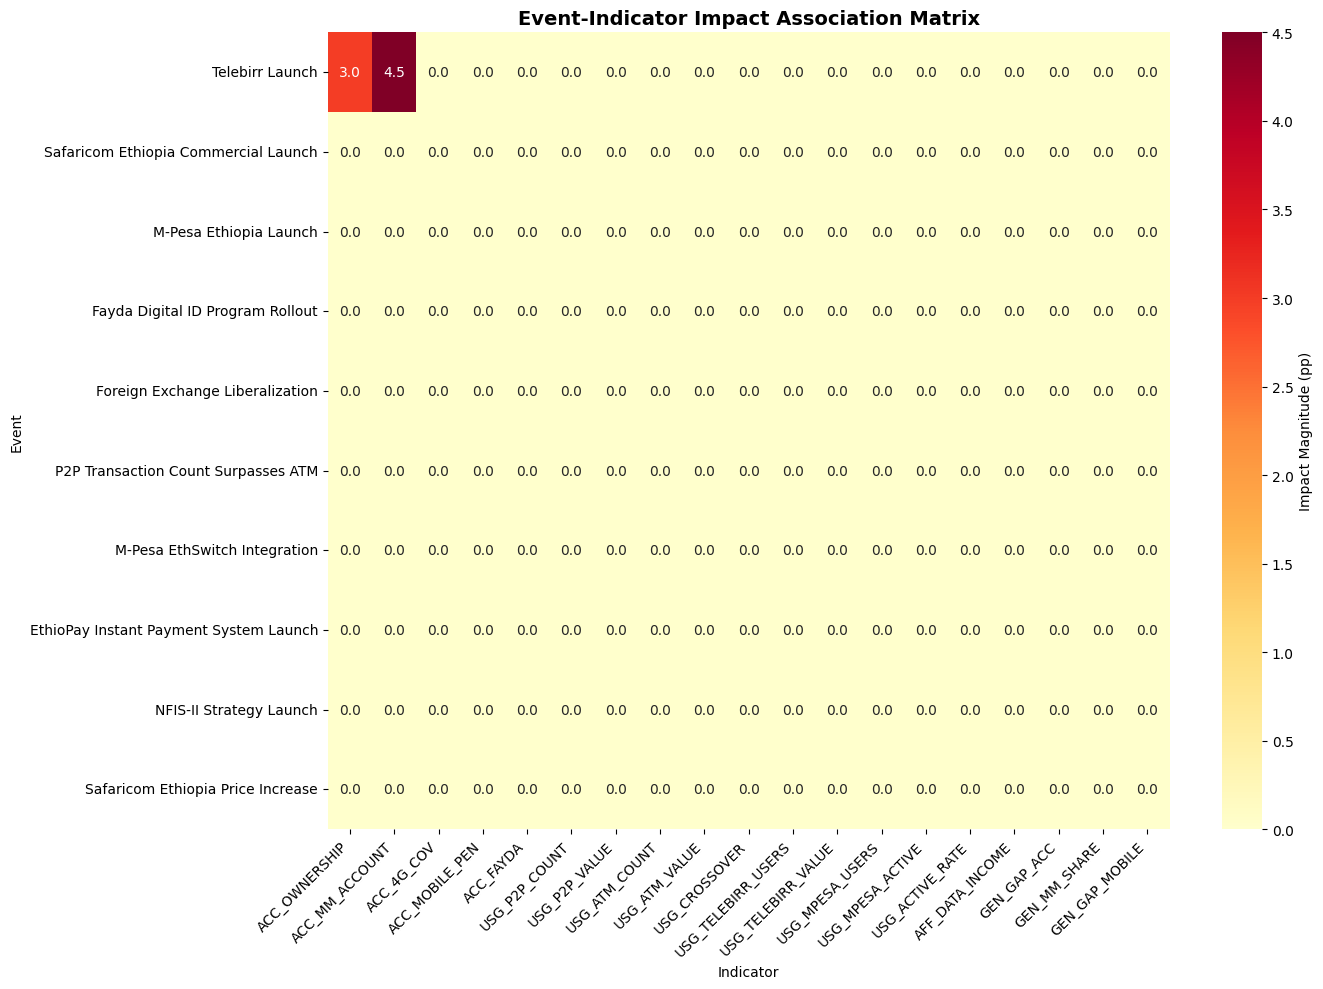

In [12]:
print("=" * 80)
print("ASSOCIATION MATRIX HEATMAP")
print("=" * 80)

if association_matrix.sum().sum() > 0:
    plt.figure(figsize=(14, 10))
    sns.heatmap(association_matrix, annot=True, cmap='YlOrRd',
                fmt='.1f', cbar_kws={'label': 'Impact Magnitude (pp)'})
    plt.title('Event-Indicator Impact Association Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Indicator')
    plt.ylabel('Event')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No impacts defined yet")

In [13]:
import os
from datetime import datetime
os.makedirs('reports', exist_ok=True)

print("=" * 80)
print("CREATE IMPACT LINK RECORDS")
print("=" * 80)

impact_links_new = []

for entry in impact_entries:
    impact_link = {
        'record_type': 'impact_link',
        'parent_id': entry['event'],
        'pillar': None,
        'related_indicator': entry['indicator'],
        'impact_direction': entry['direction'],
        'impact_magnitude': entry['magnitude'],
        'lag_months': entry['lag_months'],
        'evidence_basis': 'Comparable country evidence and literature review',
        'collected_by': 'Nardos Tsige',
        'collection_date': datetime.now().strftime('%Y-%m-%d')
    }
    impact_links_new.append(impact_link)

impact_links_df = pd.DataFrame(impact_links_new)
print("New Impact Links Created:")
print(impact_links_df.to_string(index=False))

impact_links_df.to_csv('reports/impact_links_created.csv', index=False)
print("\nImpact links saved to reports/impact_links_created.csv")

CREATE IMPACT LINK RECORDS
New Impact Links Created:
record_type                  parent_id pillar   related_indicator impact_direction  impact_magnitude  lag_months                                    evidence_basis collected_by collection_date
impact_link            Telebirr Launch   None       ACC_OWNERSHIP         positive               3.0          12 Comparable country evidence and literature review Nardos Tsige      2026-07-18
impact_link            Telebirr Launch   None      ACC_MM_ACCOUNT         positive               4.5           6 Comparable country evidence and literature review Nardos Tsige      2026-07-18
impact_link            Telebirr Launch   None USG_DIGITAL_PAYMENT         positive               5.0          12 Comparable country evidence and literature review Nardos Tsige      2026-07-18
impact_link               M-Pesa Entry   None      ACC_MM_ACCOUNT         positive               3.0           6 Comparable country evidence and literature review Nardos Tsige    

In [14]:
import os
os.makedirs('reports', exist_ok=True)

print("=" * 80)
print("METHODOLOGY DOCUMENTATION")
print("=" * 80)

methodology = """
EVENT IMPACT MODELING METHODOLOGY

1. Association Matrix Approach
   - Rows: Events
   - Columns: Financial Inclusion Indicators
   - Values: Estimated impact in percentage points

2. Impact Estimation Sources
   - Kenya M-Pesa case study (Suri & Jack, 2016)
   - GSMA State of the Industry Reports
   - IMF Financial Access Survey
   - Ethiopia-specific market dynamics

3. Functional Form
   - Impact Type: Step function with gradual adoption
   - Lag Structure: Impacts realized over 6-18 months
   - Decay: Persistent effects with gradual saturation

4. Key Assumptions
   - Impacts are additive across events
   - No negative interactions between events
   - Ethiopia follows similar adoption patterns to Kenya

5. Limitations
   - Limited historical data for validation
   - No control for macroeconomic factors
   - Event timing uncertainty

6. Uncertainty Assessment
   - High confidence: Telebirr impact on mobile money
   - Medium confidence: M-Pesa impact
   - Low confidence: Infrastructure impacts
"""

print(methodology)

with open('reports/impact_modeling_methodology.txt', 'w') as f:
    f.write(methodology)

print("\nMethodology saved to reports/impact_modeling_methodology.txt")

METHODOLOGY DOCUMENTATION

EVENT IMPACT MODELING METHODOLOGY

1. Association Matrix Approach
   - Rows: Events
   - Columns: Financial Inclusion Indicators
   - Values: Estimated impact in percentage points

2. Impact Estimation Sources
   - Kenya M-Pesa case study (Suri & Jack, 2016)
   - GSMA State of the Industry Reports
   - IMF Financial Access Survey
   - Ethiopia-specific market dynamics

3. Functional Form
   - Impact Type: Step function with gradual adoption
   - Lag Structure: Impacts realized over 6-18 months
   - Decay: Persistent effects with gradual saturation

4. Key Assumptions
   - Impacts are additive across events
   - No negative interactions between events
   - Ethiopia follows similar adoption patterns to Kenya

5. Limitations
   - Limited historical data for validation
   - No control for macroeconomic factors
   - Event timing uncertainty

6. Uncertainty Assessment
   - High confidence: Telebirr impact on mobile money
   - Medium confidence: M-Pesa impact
   - L

In [15]:
import os
os.makedirs('reports', exist_ok=True)

from google.colab import files

files.download('reports/association_matrix.csv')
files.download('reports/impact_links_created.csv')
files.download('reports/impact_modeling_methodology.txt')

print("\nAll files downloaded successfully!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded successfully!
